# Predicting Music Popularity with tree-based models

# Introduction
**How well can we predict the popularity of a song on Spotify using machine learning models?**

There is a considerable amount of literature on predicting music popularity using audio features, and many of them apply classification models to determine whether a song is within a certain "bucket" of popularity (top 50 in the charts, popular vs. non-popular). Some papers have demonstrated that tree-based models perform well for classifying songs by popularity.

# Overview

In this assignment, we will practice building a machine learning system with the following guided tasks:

1) **Task 1**: Conduct exploratory data analysis and select representative features

2) **Task 2**: Implement and fine-tune a decision tree classifier, visualize and interprete the model to understand the relationship between the audio features and music popularity

3) **Task 3**: Implement a random forest classifier and compare it with a decision tree classifier to understand the pros and cons of each model

4) **Task 4**: Implement a decision tree regressor and compare it with the decision tree classifier to understand the differences between classification and regression models

5) **Optional task**: Explore how does different data preprocessing steps affect the performance of the decision tree classifier explored in Task2


# Data

This [Spotify](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) dataset contains over a range of 125 different genres. Each song/track is represented by 20 features (include meta data and audio features) and an indicator of popularity.

In [1]:
# important machine learning and visualization libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

import graphviz
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Exploratory Data Analysis

In [3]:
# import the dataset as a dataframe
data_path = '/Users/zhengyiglasgow/Documents/2026 q1 UChicago y1q2/introduction to machine learning/m2 treebased/tracks.csv'
df_data = pd.read_csv(data_path, index_col="sample_id")

# The dataset has 114,000 samples and 21 columns.
df_data.shape

(114000, 20)

In [4]:
# first 5 rows of the dataframe
df_data.head(5)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
sample_id,,,,,,,,,,,,,,,,,,,,
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
# Print the feature variables
print(df_data.columns)

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')


Check **missing** values and deal with missing values if necessary (refer to M1_EDA).

In [6]:
# check missing values in the dataset

df_data.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

One missing value for each of the three columns: `artists`, `album_name`, `track_name`. You can either remove samples that contain missing values, or ignore the missing values for now.

## Explore the target variable
- Target variable: `popularity`

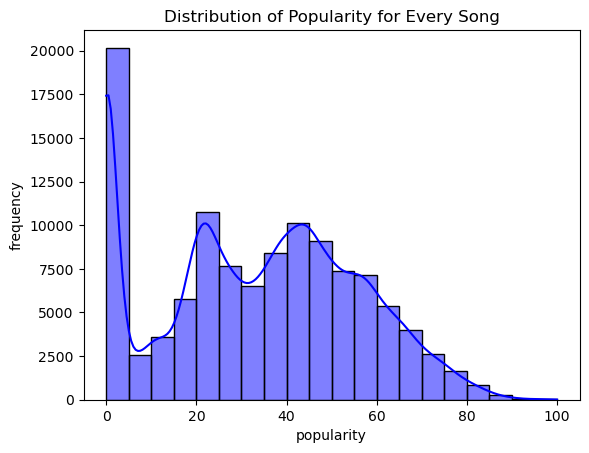

In [7]:
# check the distribution of "popularity"

sns.histplot(df_data['popularity'], kde=True, bins=20, color="blue")
plt.xlabel("popularity")
plt.ylabel("frequency")
plt.title("Distribution of Popularity for Every Song")
plt.show()

In [8]:
# check the number of tracks where "popularity" is 0

(df_data['popularity'] == 0).sum()

np.int64(16020)

In [9]:
# drop all samples whose "popularity" is 0

df_data = df_data[df_data['popularity'] != 0]
df_data.shape

(97980, 20)

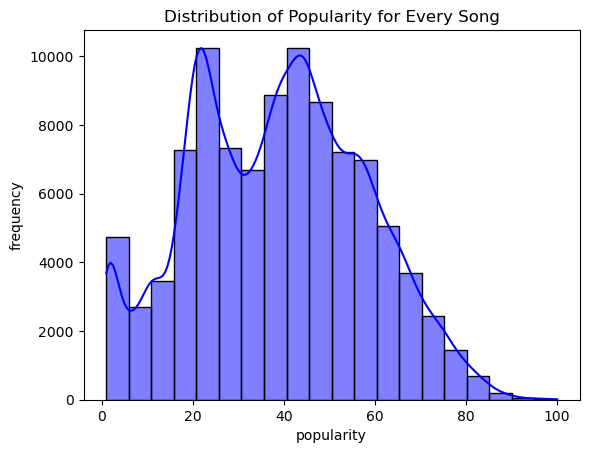

In [ ]:
# plot the distribution of "popularity" from the new sample

sns.histplot(df_data['popularity'], kde=True, bins=20, color="blue")
plt.xlabel("popularity")
plt.ylabel("frequency")
plt.title("Distribution of Popularity for Every Song")
plt.show()

### Binarize the target variable
- Calculate the average popularity and find a threshold to binarize the popularity for each sample

In [11]:
avg = df_data['popularity'].mean()
df_data['popularity_label'] = df_data['popularity'].apply(lambda x: 1 if x>= avg else 0)

<Axes: title={'center': 'Popularity distribution'}, xlabel='popularity_label'>

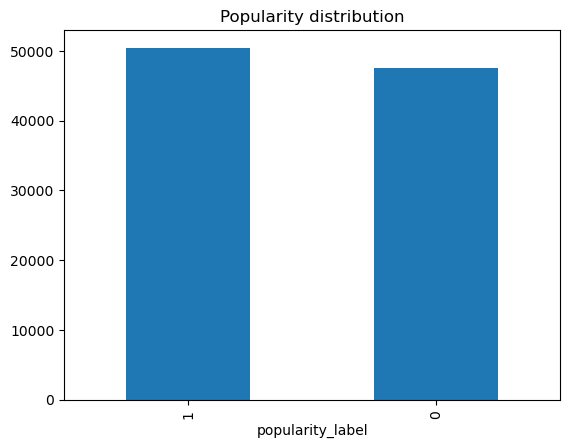

In [12]:
df_data['popularity_label'].value_counts().plot(kind='bar', title="Popularity distribution")

The dataset is almost **equally distributed (balanced)**, which is great for building a ML model.

## Explore feature variables

We select 14 features (10 numerical and 4 categorical) from the original dataset to construct a new dataframe for exploration in this task. We will process each type of feature separately.

In [13]:
# cat_features: categorical features; num_features: numerical features
cat_features = ['popular_genre', 'explicit', 'mode', 'time_signature']
num_features = ['duration_min', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
                'instrumentalness', 'liveness', 'valence', 'tempo']

### Categorical feature processing

In terms of music popularity, the genre of the song/track is a strong predictive factor. In this step, we will first create an additional categorical feature, **popular_genre**, to indicate whether the genre of a song is popular, and replace the original categorical feature "track_genre".

In [14]:
# Calculate the average popularity of the tracks by genre

genre_popularity = []
uniq_genres = df_data['track_genre'].unique()
for genre in uniq_genres:
    m = df_data[df_data["track_genre"] == genre]["popularity"].mean()
    genre_popularity.append((genre, round(m,1)))
df_genre = pd.DataFrame(genre_popularity, columns=['genre', 'mean_popularity'])
df_sorted = df_genre.sort_values(by='mean_popularity', ascending = False)
df_sorted.head(20)

,genre,mean_popularity
80,pop-film,59.4
65,k-pop,59.2
81,pop,58.2
31,electro,57.9
53,house,57.2
15,chill,55.9
71,metal,55.0
30,edm,54.9
56,indie-pop,54.9
57,indie,54.5


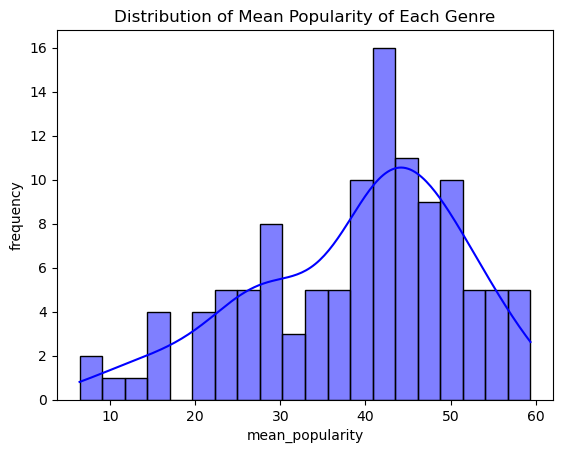

In [15]:
# show the distribution of mean popularity by genre

sns.histplot(df_sorted['mean_popularity'], kde=True, bins=20, color="blue")
plt.xlabel("mean_popularity")
plt.ylabel("frequency")
plt.title("Distribution of Mean Popularity of Each Genre")
plt.show()

Based on this histogram plot, we will **use 30 as the threshold** to determine whether the genre of a track/song is popular or not and create a new binary feature **popular_genre** to replace **track_genre**.

In [16]:
df_data['popular_genre'] = 0
lst_genre = df_sorted[df_sorted['mean_popularity'] >= 30]['genre'].unique()
df_data.loc[df_data['track_genre'].isin(lst_genre), 'popular_genre'] = 1

In [17]:
df_data.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity_label,popular_genre
sample_id,,,,,,,,,,,,,,,,,,,,,
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,1,1
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,1,1
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,1,1
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,1,1
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,1,1


### Categorical feature processing

We will first check the **distribution** of each categorical feature and then **encode** each feature separately.

**popular_genre**

In [18]:
df_data['popular_genre'].value_counts()

popular_genre
1    72967
0    25013
Name: count, dtype: int64

**explicit**

In [19]:
df_data['explicit'].value_counts()

explicit
False    89538
True      8442
Name: count, dtype: int64

**mode**

In [20]:
df_data['mode'].value_counts()

mode
1    62169
0    35811
Name: count, dtype: int64

**time_signature**

In [21]:
df_data['time_signature'].value_counts()

time_signature
4    87886
3     7560
5     1530
1      845
0      159
Name: count, dtype: int64

In [22]:
# convert "time_signature" into a binary variable based on whether the track is in 4/4

df_data['time_signature'] = df_data['time_signature'].apply(lambda x: 1 if x == 4 else 0)

- According to the distribution of each categorical feature, we will apply OneHotEncoder for each feature.
- Later on, we will have an additional discussion about **whether it is necessary** to encode categorical features and if we don't encode categorical features, how will this affect model performance.

In [23]:
df_data.time_signature.value_counts()

time_signature
1    87886
0    10094
Name: count, dtype: int64

In [24]:
df_data[cat_features].head()

,popular_genre,explicit,mode,time_signature
sample_id,,,,
0,1,False,0,1
1,1,False,1,1
2,1,False,1,1
3,1,False,1,0
4,1,False,1,1


Apply **OneHotEncoding** for each categorical variable

In [25]:
# Initiate a one-hot encoder
ohe = OneHotEncoder(handle_unknown='ignore')
df_cat = df_data[cat_features]
ohe.fit(df_cat)

# # encode the features with the fitted encoder
df_cat_ohe = pd.DataFrame(ohe.transform(df_cat).toarray())

# rename columns to make it expressive
col_names = []
for i in range(len(cat_features)):
    for j in ohe.categories_[i]:
        col_names.append(cat_features[i] + '_' + str(j))

names_dict = {i:col_names[i] for i in range(len(col_names))}
df_cat_ohe.rename(columns=names_dict, inplace=True)
df_cat_ohe.index = df_data.index # add an index column to keep track of each sample

In [26]:
df_cat_ohe.head()

,popular_genre_0,popular_genre_1,explicit_False,explicit_True,mode_0,mode_1,time_signature_0,time_signature_1
sample_id,,,,,,,,
0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
2,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
3,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
4,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0


### Numerical feature processing

Check the data distribution and outliers of each numerical variable.

In [29]:
# Create a function for this part to organize the code
def clean_numerical(df, col):
    '''takes a dataset df and a column name col as input'''

    # draw boxplot of the column
    plt.figure(figsize=(6, 4));
    sns.boxplot(x=df[col])
    plt.title("Boxplot of %s for Every Song" % col)
    plt.show();
    plt.clf()

    print(df.shape)
    # remove outliers
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    # visualize the histogram of the cleaned data
    sns.histplot(df[col], kde=True, bins=20, color="blue")
    plt.title("Distribution of %s after remove outliers" % col)
    plt.show();
    plt.clf()

    # scale the feature
    scaler = MinMaxScaler()
    df.loc[:, col] = scaler.fit_transform(df[[col]])
    print("Successfully scaled the feature: %s" % col)

    return df

**duration_min**

In [30]:
# change the unit for duration into minute and rename the column

df_data['duration_ms'] = df_data['duration_ms'] * 1000 / 60
df_data.rename(columns={'duration_ms': 'duration_min'}, inplace=True)

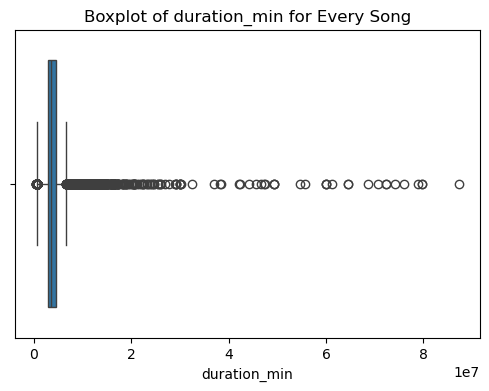

(97980, 22)


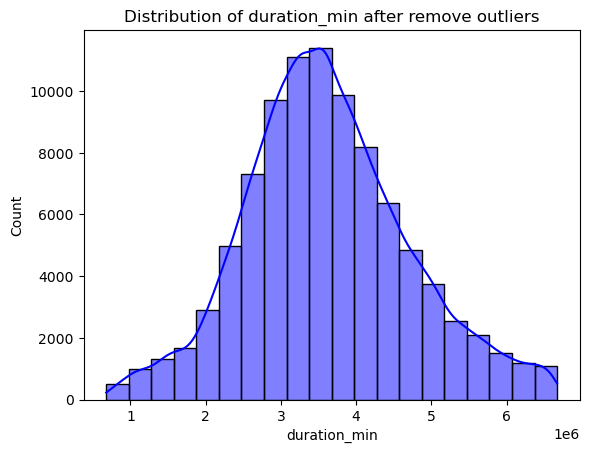

Successfully scaled the feature: duration_min


<Figure size 640x480 with 0 Axes>

In [31]:
df_data = clean_numerical(df_data, col='duration_min')

**danceability**

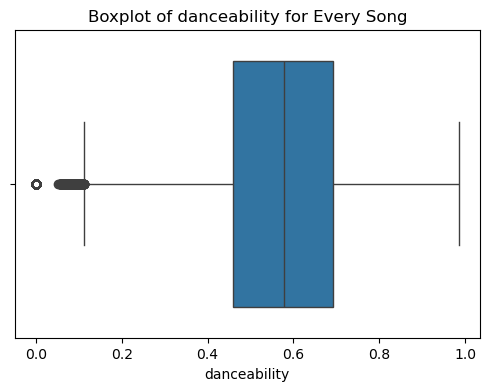

(93353, 22)


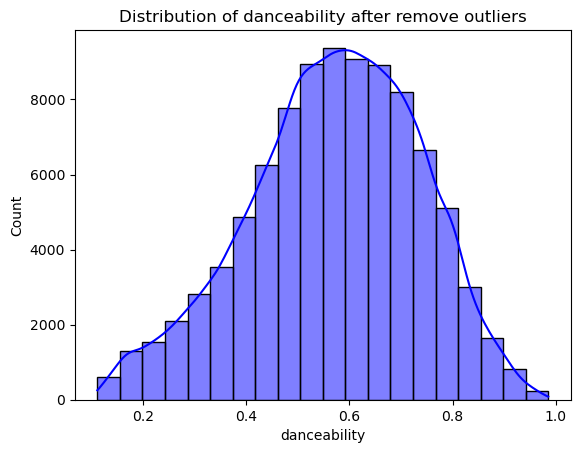

Successfully scaled the feature: danceability


<Figure size 640x480 with 0 Axes>

In [32]:
df_data = clean_numerical(df_data, col='danceability')

**energy**

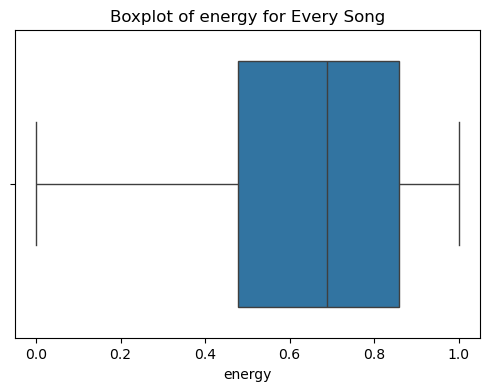

(92771, 22)


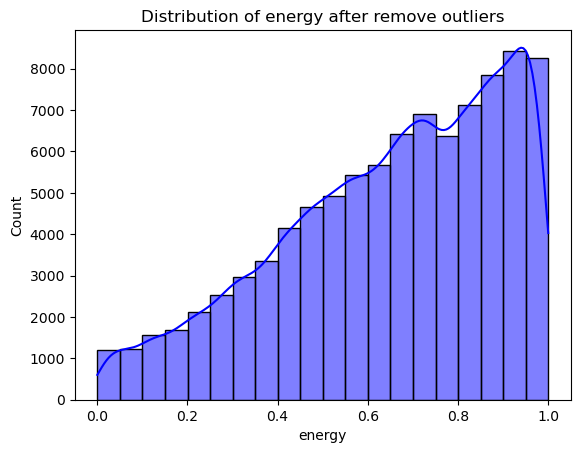

Successfully scaled the feature: energy


<Figure size 640x480 with 0 Axes>

In [33]:
df_data = clean_numerical(df_data, col='energy')

**loudness**

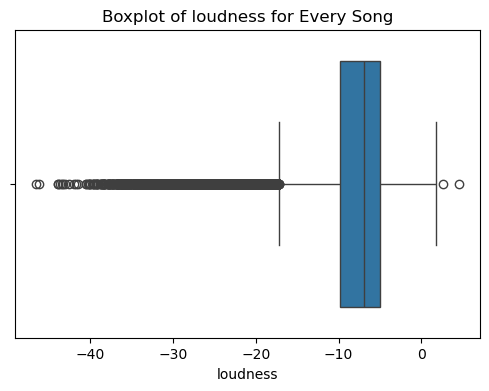

(92771, 22)


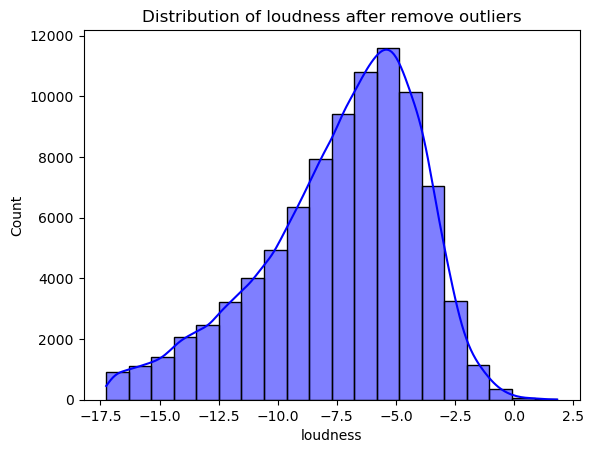

Successfully scaled the feature: loudness


<Figure size 640x480 with 0 Axes>

In [34]:
df_data = clean_numerical(df_data, col='loudness');

**speechiness**

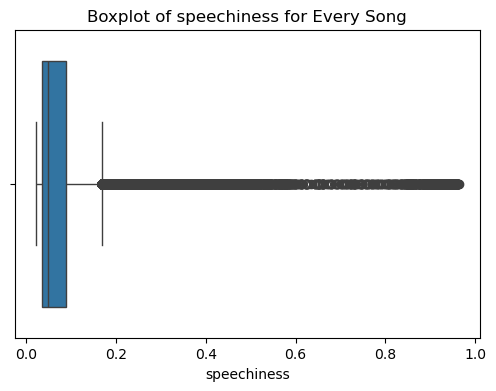

(88228, 22)


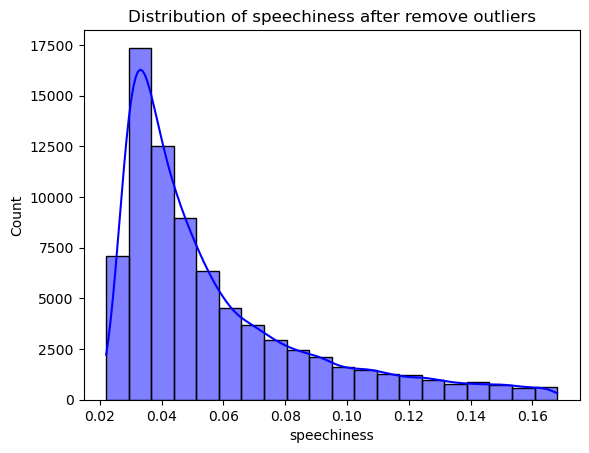

Successfully scaled the feature: speechiness


<Figure size 640x480 with 0 Axes>

In [35]:
df_data = clean_numerical(df_data, col='speechiness');

**acousticness**

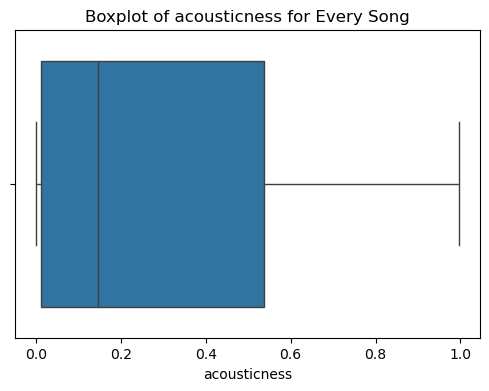

(78138, 22)


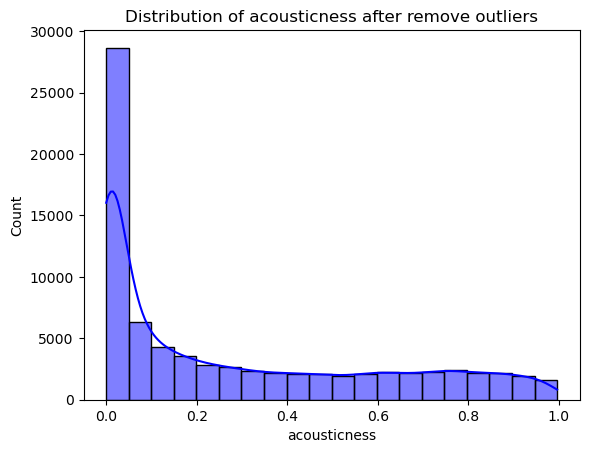

Successfully scaled the feature: acousticness


<Figure size 640x480 with 0 Axes>

In [36]:
df_data = clean_numerical(df_data, col='acousticness');

**instrumentalness**

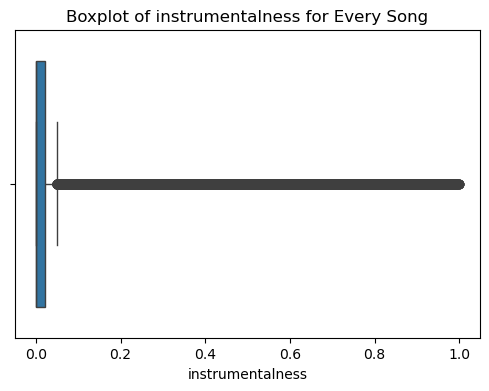

(78138, 22)


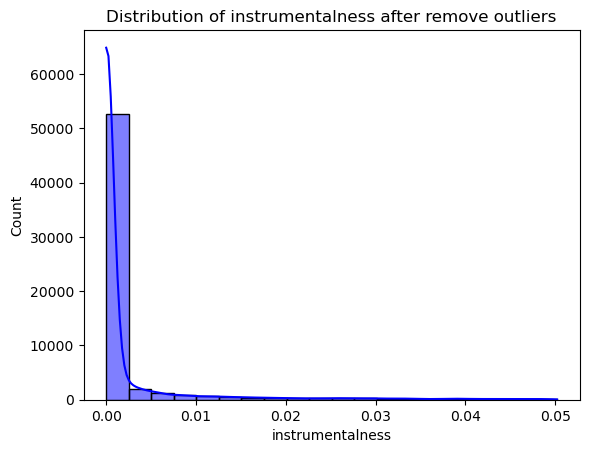

Successfully scaled the feature: instrumentalness


<Figure size 640x480 with 0 Axes>

In [37]:
df_data = clean_numerical(df_data, col='instrumentalness')

**liveness**

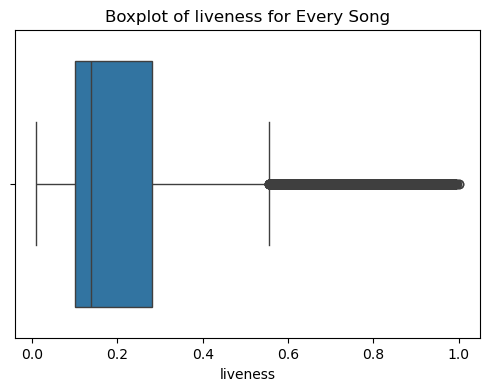

(60869, 22)


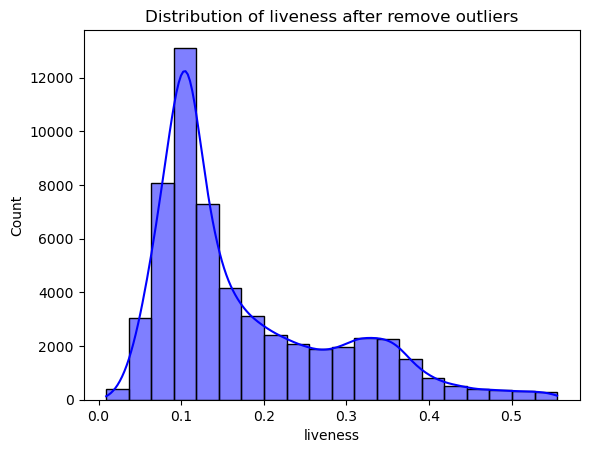

Successfully scaled the feature: liveness


<Figure size 640x480 with 0 Axes>

In [38]:
df_data = clean_numerical(df_data, col='liveness')

**valence**

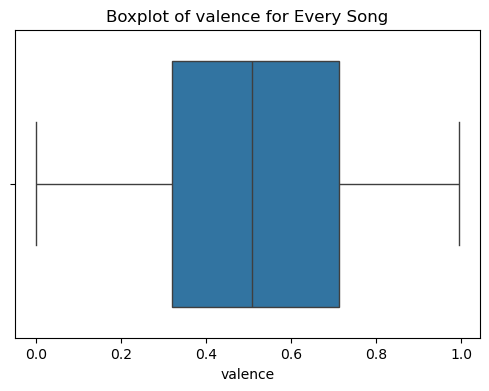

(56406, 22)


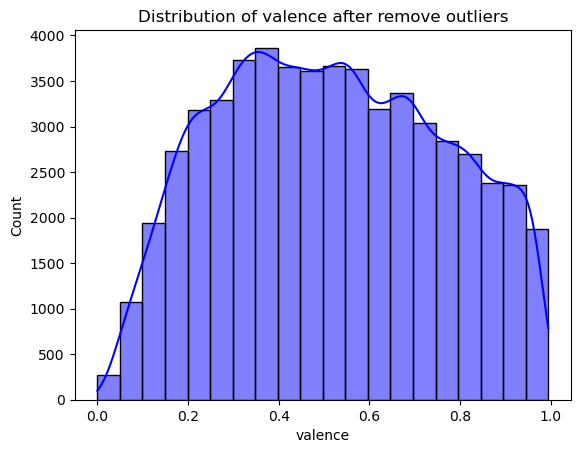

Successfully scaled the feature: valence


<Figure size 640x480 with 0 Axes>

In [39]:
df_data = clean_numerical(df_data, col='valence')

**tempo**

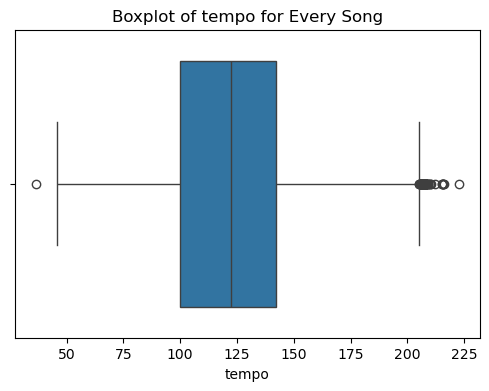

(56406, 22)


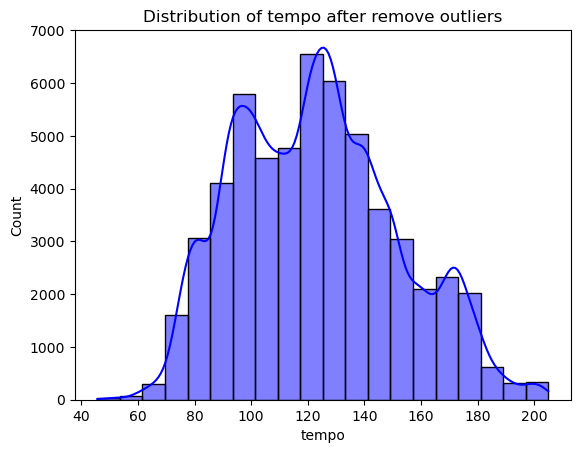

Successfully scaled the feature: tempo


<Figure size 640x480 with 0 Axes>

In [40]:
df_data = clean_numerical(df_data, col='tempo')

#### **Task 1.1: Feature Discussion**

We now have a large number of box and whisker plots and histograms showing us the within-group distributions of our features. You can never be too familiar with your data, so before moving any further let's pause a second to observe the distributions.


> __Your Task__: Take a moment and look at the above plots. What differences do you observe between the distributions of our variables? Do any seem have particularly nice (e.g. normal) distributions? Do any seem particularly skewed? Make two to three observations. Hypothesizing, are there any features which you believe will be highly predictive of whether a song is popular or not?

>_NB: Generally speaking, we do not expect any long text responses in this assignment to take more than a paragraph. In fact, some prompts can likely be addressed in a sentence or two, so just use however much (or little!) room you need to fully address the prompt._


(Your answer, here)

1.1
Particularly nice distributions: duration_min & dancability

Particularly skewed: liveness(left-skewed), instrumentalness(left-skewed), acousticness(left-skewed), speechiness(left-skewed), energy(right-skewed)

Hypothesis: liveness. Since the distribution of it is more similar to the distribution of popularity.

**Check feature colinearty**

After processing the features and investigating their distributions, we now plot a heatmap to investigate the correlation between every two features.

***Note***: *correlation heatmaps like that below can be really useful in your own work, so take note of how this was made!*

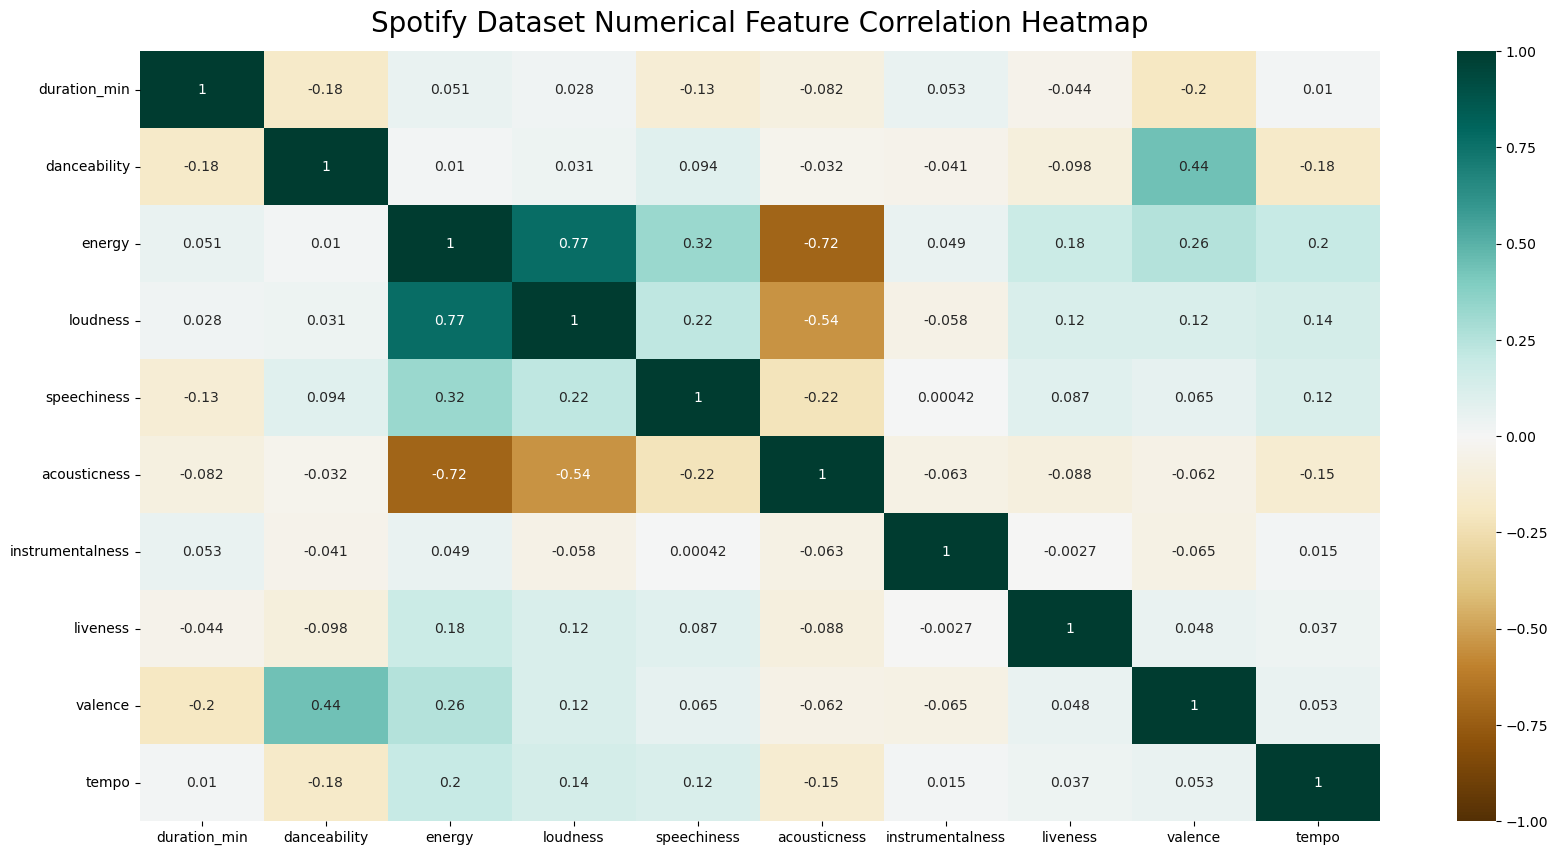

In [41]:
# set the size of the heatmap.
plt.figure(figsize=(20, 10))
heatmap = sns.heatmap(df_data[num_features].corr(), vmin=-1, vmax=1, annot=True, cmap='BrBG')
# Set the title
heatmap.set_title('Spotify Dataset Numerical Feature Correlation Heatmap', fontdict={'fontsize':20}, pad=14);

#### **Task 1.2: Feature Trimming**

If we identify a pair of highly correlated features (i.e. features with $\vert \text{correlation}\vert \geq 0.7$), we will only keep one and remove the others.

> __Your Task__: Use the above correlation plot to identify highly correlated pairs of features. Define a list `new_num_features` which is just `num_features` but without highly correlated features. Then, explain why we want to remove highly correlated features. What problems can these pose for our models?

In [75]:
# we create a new list of numerical features by removing 'energy'
new_num_features = ['duration_min', 'danceability', 'loudness', 'speechiness', 'acousticness',
                'instrumentalness', 'liveness', 'valence', 'tempo']

## Finalize the feature matrix
- We now construct the final data matrix from the processed numerical and categorical features
- We then split the data matrix into training and testing to prepare for model training

In [76]:
X_data = pd.merge(df_data[new_num_features], df_cat_ohe, left_index=True, right_index=True, how='inner')

feature_names = X_data.columns.to_list()
X_data.shape

(56332, 17)

In [77]:
# Create target variable
y_data = df_data[['popularity_label']]
y_data.shape

(56332, 1)

In [78]:
# Split the data into training and testing
X_train, X_test, y_train, y_test  = train_test_split(X_data, y_data, test_size = 0.3, random_state = 42)

In [79]:
# Check the shape of training and testing feature matrix
X_train.shape, X_test.shape

((39432, 17), (16900, 17))

In [80]:
# Check the data distributon of the target variable in training and testing set
print("training:", y_train.value_counts(),'\n')
print("testing:", y_test.value_counts())

training: popularity_label
1                   22389
0                   17043
Name: count, dtype: int64 

testing: popularity_label
1                   9714
0                   7186
Name: count, dtype: int64


# Model training and testing

We've now finished exploring our initial dataset and created two mini datasets: a **training** dataset consistng of `X_train` and `y_train`; and a **testing** dataset consisting of `X_test` and `y_test`.

We will use the training set to train our models, and then we will evaluate model performance on the held-out testing data. In this section, you will go through this process for three types of tree-based models:

> 1) Decision Tree Classifier

> 2) Random Forest Classifier

> 3) Decision Tree Regressor



## Task 2: Decision tree classifier

The first of the three models we will explore is the __Decision Tree Classifier__, which uses a series of binary choices to predict the category a given observation belongs to. You can read the documentation for the `sklearn` implementation of the classifier [here](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html).

![Simple Decision Tree Classifier, stolen ruthlessly from an Ecosia search](https://ieftimov.com/posts/classifier-decision-trees/index_files/decision-tree-graphic.png)

> __Your Task__: Import the `DecisionTreeClasisfier` class from `sklearn.tree`. Create a classifier named `dt_clf` with a `random_state` of 42. `fit` the classifier on your training data, and then caclulate the `score` of `dt_clf` on the testing data. Interpret the score metric: is the model performing well or poorly?

In [49]:
# Import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

# Create a classifier with random_state=42
dt_clf = DecisionTreeClassifier(random_state=42)

# Fit the classifier on training data
dt_clf.fit(X_train, y_train.values.ravel())

# Calculate and display the score on testing data
test_score = dt_clf.score(X_test, y_test.values.ravel())
print(f"Decision Tree Classifier Test Score: {test_score:.4f}")


Decision Tree Classifier Test Score: 0.7238


The score is 0.7238, performing moderately well.

Now that we've tried the model with it's default parameters, we should explore different hyperparameter settings to improve the model performance.

> __Your Task__: First, explore how the model's results change with different hyperparameter settings. For instance, check how different combinations of values for `criterion`, `max_depth`, `min_samples_split`, and `min_samples_leaf` impact the model's performance. Keep track of the best performing set of hyperparameters for use in the next step.

> Then, briefly discuss what you find and how your findings relate to the pros and cons of decision trees. If you are unable to improve the score through hyperparameyer tuning, try to explain the reason based on what we learned in class.

In [51]:
  # STEP 1: Find the best max_depth first
  print("STEP 1: Finding the best max_depth")
  print("="*60)
  max_depths = [3, 5, 7, 10, 15, 20, None]

  best_depth_score = 0
  best_depth = None

  for depth in max_depths:
      clf = DecisionTreeClassifier(random_state=42, max_depth=depth)
      clf.fit(X_train, y_train.values.ravel())
      train_score = clf.score(X_train, y_train.values.ravel())
      test_score = clf.score(X_test, y_test.values.ravel())
      print(f"max_depth={depth}: Train={train_score:.4f}, Test={test_score:.4f}")

      if test_score > best_depth_score:
          best_depth_score = test_score
          best_depth = depth

  print(f"\nBest max_depth: {best_depth} with test score: {best_depth_score:.4f}")


STEP 1: Finding the best max_depth
max_depth=3: Train=0.7054, Test=0.7104
max_depth=5: Train=0.7145, Test=0.7196
max_depth=7: Train=0.7239, Test=0.7133
max_depth=10: Train=0.7568, Test=0.7222
max_depth=15: Train=0.8531, Test=0.7220
max_depth=20: Train=0.9352, Test=0.7269
max_depth=None: Train=0.9932, Test=0.7238

Best max_depth: 20 with test score: 0.7269


In [57]:
  # Continue hyperparameter tuning with max_depth=20 and criterion='entropy'
  from sklearn.tree import DecisionTreeClassifier

  best_depth = 20
  best_criterion = 'entropy'

  print("="*60)
  print(f"STEP 2: Testing min_samples_split")
  print(f"Using max_depth={best_depth}, criterion={best_criterion}")
  print("="*60)

  min_samples_splits = [2, 5, 10, 20, 50, 100]

  best_split_score = 0
  best_split = 2

  for split in min_samples_splits:
      clf = DecisionTreeClassifier(random_state=42, criterion=best_criterion,
                                   max_depth=best_depth, min_samples_split=split)
      clf.fit(X_train, y_train.values.ravel())
      train_score = clf.score(X_train, y_train.values.ravel())
      test_score = clf.score(X_test, y_test.values.ravel())
      print(f"min_samples_split={split}: Train={train_score:.4f}, Test={test_score:.4f}")

      if test_score > best_split_score:
          best_split_score = test_score
          best_split = split

  print(f"\nBest min_samples_split: {best_split} with test score: {best_split_score:.4f}")

  # STEP 3: Test min_samples_leaf
  print("\n" + "="*60)
  print(f"STEP 3: Testing min_samples_leaf")
  print(f"Using max_depth={best_depth}, criterion={best_criterion}, min_samples_split={best_split}")
  print("="*60)

  min_samples_leafs = [1, 2, 5, 10, 20, 50]

  best_leaf_score = 0
  best_leaf = 1

  for leaf in min_samples_leafs:
      clf = DecisionTreeClassifier(random_state=42, criterion=best_criterion,
                                   max_depth=best_depth, min_samples_split=best_split,
                                   min_samples_leaf=leaf)
      clf.fit(X_train, y_train.values.ravel())
      train_score = clf.score(X_train, y_train.values.ravel())
      test_score = clf.score(X_test, y_test.values.ravel())
      print(f"min_samples_leaf={leaf}: Train={train_score:.4f}, Test={test_score:.4f}")

      if test_score > best_leaf_score:
          best_leaf_score = test_score
          best_leaf = leaf

  print(f"\nBest min_samples_leaf: {best_leaf} with test score: {best_leaf_score:.4f}")

  # FINAL SUMMARY
  print("\n" + "="*60)
  print("FINAL BEST HYPERPARAMETERS:")
  print("="*60)
  print(f"Criterion: {best_criterion}")
  print(f"Max Depth: {best_depth}")
  print(f"Min Samples Split: {best_split}")
  print(f"Min Samples Leaf: {best_leaf}")
  print(f"Best Test Score: {best_leaf_score:.4f}")
  print(f"Baseline Test Score: 0.7238")
  print(f"Improvement: {(best_leaf_score - 0.7238):.4f} ({(best_leaf_score - 0.7238)*100:.2f}%)")

  # Store for next task
  best_max_depth = best_depth
  best_min_samples_split = best_split
  best_min_samples_leaf = best_leaf



STEP 2: Testing min_samples_split
Using max_depth=20, criterion=entropy
min_samples_split=2: Train=0.9170, Test=0.7353
min_samples_split=5: Train=0.9082, Test=0.7308
min_samples_split=10: Train=0.8876, Test=0.7250
min_samples_split=20: Train=0.8547, Test=0.7172
min_samples_split=50: Train=0.8052, Test=0.7122
min_samples_split=100: Train=0.7747, Test=0.7141

Best min_samples_split: 2 with test score: 0.7353

STEP 3: Testing min_samples_leaf
Using max_depth=20, criterion=entropy, min_samples_split=2
min_samples_leaf=1: Train=0.9170, Test=0.7353
min_samples_leaf=2: Train=0.9008, Test=0.7272
min_samples_leaf=5: Train=0.8694, Test=0.7199
min_samples_leaf=10: Train=0.8312, Test=0.7126
min_samples_leaf=20: Train=0.7897, Test=0.7095
min_samples_leaf=50: Train=0.7491, Test=0.7040

Best min_samples_leaf: 1 with test score: 0.7353

FINAL BEST HYPERPARAMETERS:
Criterion: entropy
Max Depth: 20
Min Samples Split: 2
Min Samples Leaf: 1
Best Test Score: 0.7353
Baseline Test Score: 0.7238
Improvement: 

One of the primary benefits of decision trees is that they are _inherently interpretable_ models, meaning we have multiple methods to easily understand why the model makes the decisions it does. In the following steps, we'll explore the relationships learned by your best performing decision tree classifier.

> __Your Task__: In the previous step, you explored groups of potential hyperparameters. Create a model with the highest performing set of hyperparameters called `best_dt_clf`. Then, use `graphviz` to visualize the tree. What patterns do you see in the tree? Which features are split on early, and which are split on later?

In [60]:
  import os
  os.environ['PATH'] = '/opt/homebrew/bin:' + os.environ.get('PATH', '')
  print("PATH updated!")

PATH updated!


Best Decision Tree Classifier Performance:
Training Score: 0.9170
Testing Score: 0.7353

Visualizing top 5 levels of the tree for clarity...


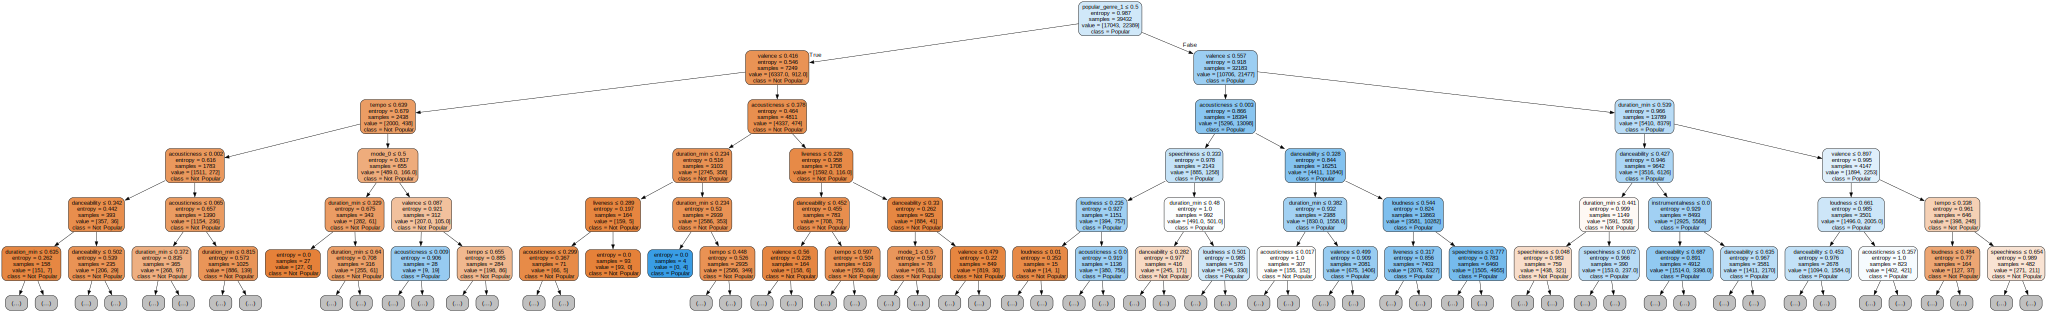

In [61]:
  # Create the best performing Decision Tree Classifier
  from sklearn.tree import DecisionTreeClassifier
  import graphviz
  from sklearn import tree

  # Use the best hyperparameters found from tuning
  best_dt_clf = DecisionTreeClassifier(
      criterion='entropy',
      max_depth=20,
      min_samples_split=2,
      min_samples_leaf=1,
      random_state=42
  )

  # Fit on training data
  best_dt_clf.fit(X_train, y_train.values.ravel())

  # Check performance
  train_score = best_dt_clf.score(X_train, y_train.values.ravel())
  test_score = best_dt_clf.score(X_test, y_test.values.ravel())
  print(f"Best Decision Tree Classifier Performance:")
  print(f"Training Score: {train_score:.4f}")
  print(f"Testing Score: {test_score:.4f}")

  # Visualize the tree (limit depth for readability since full tree is very large)
  print("\nVisualizing top 5 levels of the tree for clarity...")
  dot_data = tree.export_graphviz(
      best_dt_clf,
      out_file=None,
      feature_names=feature_names,
      class_names=['Not Popular', 'Popular'],
      filled=True,
      rounded=True,
      special_characters=True,
      max_depth=5  # Only show first 5 levels for readability
  )
  graph = graphviz.Source(dot_data)
  graph

As discussed in class, decision trees split on features with the goal of making the largest reduction in a criterion function, such as entropy. This also means that decision trees have a natural concept of feature importance: the importance of a given feature is the sum of the reduction in uncertainty/impurity for each node on which the feature is split.

> __Your Task__: Extract the `feature_importances_` from `best_dt_clf`, and create a DataFrame showing each feature and its importance. Sort the results in descending order of importance, and print the result.

> Your result table should look like the below table, but with many more rows (and potentially different values, make sure to round all values to 2 digits).

>features | importances
>----------|-------------
>popular_genre_1    |0.14
>tempo|0.1
>valence       | 0.1

> After making your table, answer the discussion questions below.



Feature Importances for Best Decision Tree Classifier:
            features  importances
0    popular_genre_1         0.19
1              tempo         0.10
2            valence         0.10
3           loudness         0.10
4       acousticness         0.10
5       danceability         0.09
6       duration_min         0.09
7        speechiness         0.09
8           liveness         0.07
9   instrumentalness         0.06
10            mode_0         0.01
11   popular_genre_0         0.00
12    explicit_False         0.00
13     explicit_True         0.00
14            mode_1         0.00
15  time_signature_0         0.00
16  time_signature_1         0.00


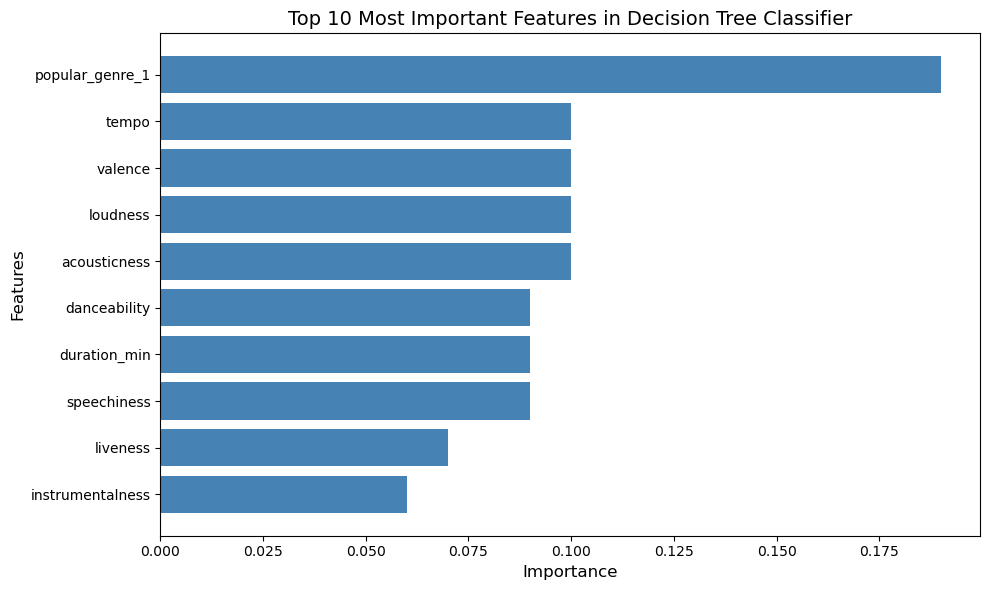

In [62]:
  # Get feature importances
  importances = best_dt_clf.feature_importances_

  # Create a DataFrame with features and their importances
  feature_importance_df = pd.DataFrame({
      'features': feature_names,
      'importances': np.round(importances, 2)
  })

  # Sort by importance in descending order
  feature_importance_df = feature_importance_df.sort_values(by='importances', ascending=False)

  # Reset index for clean display
  feature_importance_df = feature_importance_df.reset_index(drop=True)

  print("Feature Importances for Best Decision Tree Classifier:")
  print("="*50)
  print(feature_importance_df)

  # Optionally, visualize top 10 features
  import matplotlib.pyplot as plt

  top_n = 10
  top_features = feature_importance_df.head(top_n)

  plt.figure(figsize=(10, 6))
  plt.barh(top_features['features'], top_features['importances'], color='steelblue')
  plt.xlabel('Importance', fontsize=12)
  plt.ylabel('Features', fontsize=12)
  plt.title(f'Top {top_n} Most Important Features in Decision Tree Classifier', fontsize=14)
  plt.gca().invert_yaxis()
  plt.tight_layout()
  plt.show()

**Discussion Q1. What can we take away from the above results? What features explain the most variations? Can you explain whether the top features make sense in terms of the context of music?**


The popular_genre (0.19) is by far the most influential predictor, this makes intuitive sense: certain music genres (pop, k-pop) inherently have larger audiences and better promotion, making them more likely to be popular. Then is tempo (0.10), valence (0.10), loudness (0.10), and acousticness (0.10)—all contribute equally and represent key musical qualities that affect listener appeal.

**Discussion Q2. Are these results robust? That is, to what extent can we trust these results to be indicative of true underlying trends in our dataset?**

No. Decision trees are inherently unstable—small changes in the training data or random state can produce different tree structures and feature importances.

## [Optional task] How does feature processing affect the performance of tree-based models?
In the above sections, we conduct the following data processing steps:
- for categorical features, we do one-hot encoding
- for numerical features, we checked the outlier distribution and multicollinearity, and removed highly correlated features.

In this section, you will do some free exploration to see how does the following change affect model performance:
- for categorical features, experiment by **not encoding** categorical features and check how this affects model performance
- for numerical features, experiment by **not removing outliers** for one or more numerical features and check how this affects model performance

In your exploration, write comments along with your code, discuss the results, and provide additional insights (the same style as we provided in this jupyter notebook).

In [ ]:
# Your Code Here

In [ ]:
# Your code here, too!

In [ ]:
# If you need more room for code, you have it!

## Task 3: Random Forest Classifier

The second of the three tree-based models we will explore in this notebook is the __Random Forest Classifier__, which tallies votes from a forest of Decision Tree Classifiers trained on a subset of the data to come to its conclusions. You can read the documentation for the `sklearn` implementation of the classifier [here](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).

![RF Example Image](https://liorsinai.github.io/assets/posts/random-forests/Random_forest_diagram_complete.png)

> __Your Task__: Import the `RandomForestClassifier` class from `sklearn.ensemble`. Create a classifier named `rf_clf` with a `random_state` of 42. `fit` the classifier on your training data, and then calculate the `score` of `rf_clf` on the testing data. Interpret the score metric: is the model performing poorly or well?




In [63]:
  # Import RandomForestClassifier
  from sklearn.ensemble import RandomForestClassifier

  # Create a Random Forest classifier with random_state=42
  rf_clf = RandomForestClassifier(random_state=42)

  # Fit the classifier on training data
  rf_clf.fit(X_train, y_train.values.ravel())

  # Calculate and display the score on testing data
  train_score = rf_clf.score(X_train, y_train.values.ravel())
  test_score = rf_clf.score(X_test, y_test.values.ravel())

  print(f"Random Forest Classifier Performance:")
  print(f"Training Score: {train_score:.4f}")
  print(f"Testing Score: {test_score:.4f}")
  print(f"\nComparison with Decision Tree:")
  print(f"Decision Tree Test Score: 0.7353")
  print(f"Random Forest Test Score: {test_score:.4f}")
  print(f"Improvement: {(test_score - 0.7353):.4f} ({(test_score - 0.7353)*100:.2f}%)")


Random Forest Classifier Performance:
Training Score: 0.9932
Testing Score: 0.7847

Comparison with Decision Tree:
Decision Tree Test Score: 0.7353
Random Forest Test Score: 0.7847
Improvement: 0.0494 (4.94%)


The random forest model performs better with a 4.94% of improvement.

As with the Decision Tree Classifier, we should explore how different hyperparameter settings impact model performance.

> __Your Task__: First, explore how the model's results change with different hyperparameter settings. For instance, check how different combinations of values for `criterion`, `n_estimators`, `max_features`, `max_depth`, and `min_samples_leaf` impact the model's performance. Keep track of the best performing set of hyperparameters for use in the next step, and keep `random_state=42` throughout.

> Use the best set of hyperparameters to train a model called `best_rf_clf`, and report its score metric.

In [64]:
  # STEP 1: Test different n_estimators (number of trees)
  print("STEP 1: Testing n_estimators (number of trees)")
  print("="*60)

  n_estimators_list = [50, 100, 200, 300, 500]
  best_n_score = 0
  best_n = 100

  for n in n_estimators_list:
      rf = RandomForestClassifier(random_state=42, n_estimators=n)
      rf.fit(X_train, y_train.values.ravel())
      train_score = rf.score(X_train, y_train.values.ravel())
      test_score = rf.score(X_test, y_test.values.ravel())
      print(f"n_estimators={n}: Train={train_score:.4f}, Test={test_score:.4f}")

      if test_score > best_n_score:
          best_n_score = test_score
          best_n = n

  print(f"\nBest n_estimators: {best_n} with test score: {best_n_score:.4f}")

  # STEP 2: Test criterion with best n_estimators
  print("\n" + "="*60)
  print(f"STEP 2: Testing criterion with n_estimators={best_n}")
  print("="*60)

  criterions = ['gini', 'entropy']
  best_criterion_score = 0
  best_criterion = 'gini'

  for criterion in criterions:
      rf = RandomForestClassifier(random_state=42, n_estimators=best_n, criterion=criterion)
      rf.fit(X_train, y_train.values.ravel())
      train_score = rf.score(X_train, y_train.values.ravel())
      test_score = rf.score(X_test, y_test.values.ravel())
      print(f"criterion={criterion}: Train={train_score:.4f}, Test={test_score:.4f}")

      if test_score > best_criterion_score:
          best_criterion_score = test_score
          best_criterion = criterion

  print(f"\nBest criterion: {best_criterion} with test score: {best_criterion_score:.4f}")

  # STEP 3: Test max_features
  print("\n" + "="*60)
  print(f"STEP 3: Testing max_features")
  print(f"Using n_estimators={best_n}, criterion={best_criterion}")
  print("="*60)

  max_features_list = ['sqrt', 'log2', None]  # sqrt, log2, or all features
  best_features_score = 0
  best_features = 'sqrt'

  for features in max_features_list:
      rf = RandomForestClassifier(random_state=42, n_estimators=best_n,
                                  criterion=best_criterion, max_features=features)
      rf.fit(X_train, y_train.values.ravel())
      train_score = rf.score(X_train, y_train.values.ravel())
      test_score = rf.score(X_test, y_test.values.ravel())
      print(f"max_features={features}: Train={train_score:.4f}, Test={test_score:.4f}")

      if test_score > best_features_score:
          best_features_score = test_score
          best_features = features

  print(f"\nBest max_features: {best_features} with test score: {best_features_score:.4f}")

  # STEP 4: Test max_depth
  print("\n" + "="*60)
  print(f"STEP 4: Testing max_depth")
  print(f"Using n_estimators={best_n}, criterion={best_criterion}, max_features={best_features}")
  print("="*60)

  max_depths = [10, 15, 20, 25, None]
  best_depth_score = 0
  best_depth = None

  for depth in max_depths:
      rf = RandomForestClassifier(random_state=42, n_estimators=best_n,
                                  criterion=best_criterion, max_features=best_features,
                                  max_depth=depth)
      rf.fit(X_train, y_train.values.ravel())
      train_score = rf.score(X_train, y_train.values.ravel())
      test_score = rf.score(X_test, y_test.values.ravel())
      print(f"max_depth={depth}: Train={train_score:.4f}, Test={test_score:.4f}")

      if test_score > best_depth_score:
          best_depth_score = test_score
          best_depth = depth

  print(f"\nBest max_depth: {best_depth} with test score: {best_depth_score:.4f}")

  # STEP 5: Test min_samples_leaf
  print("\n" + "="*60)
  print(f"STEP 5: Testing min_samples_leaf")
  print(f"Using all best parameters found so far")
  print("="*60)

  min_samples_leafs = [1, 2, 5, 10]
  best_leaf_score = 0
  best_leaf = 1

  for leaf in min_samples_leafs:
      rf = RandomForestClassifier(random_state=42, n_estimators=best_n,
                                  criterion=best_criterion, max_features=best_features,
                                  max_depth=best_depth, min_samples_leaf=leaf)
      rf.fit(X_train, y_train.values.ravel())
      train_score = rf.score(X_train, y_train.values.ravel())
      test_score = rf.score(X_test, y_test.values.ravel())
      print(f"min_samples_leaf={leaf}: Train={train_score:.4f}, Test={test_score:.4f}")

      if test_score > best_leaf_score:
          best_leaf_score = test_score
          best_leaf = leaf

  print(f"\nBest min_samples_leaf: {best_leaf} with test score: {best_leaf_score:.4f}")

  # FINAL: Train best model
  print("\n" + "="*60)
  print("FINAL BEST HYPERPARAMETERS:")
  print("="*60)
  print(f"n_estimators: {best_n}")
  print(f"criterion: {best_criterion}")
  print(f"max_features: {best_features}")
  print(f"max_depth: {best_depth}")
  print(f"min_samples_leaf: {best_leaf}")
  print(f"Best Test Score: {best_leaf_score:.4f}")
  print(f"Baseline RF Score: 0.7847")
  print(f"Improvement: {(best_leaf_score - 0.7847):.4f} ({(best_leaf_score - 0.7847)*100:.2f}%)")

  # Create the best model
  best_rf_clf = RandomForestClassifier(
      random_state=42,
      n_estimators=best_n,
      criterion=best_criterion,
      max_features=best_features,
      max_depth=best_depth,
      min_samples_leaf=best_leaf
  )

  best_rf_clf.fit(X_train, y_train.values.ravel())
  final_test_score = best_rf_clf.score(X_test, y_test.values.ravel())
  print(f"\nFinal best_rf_clf test score: {final_test_score:.4f}")


STEP 1: Testing n_estimators (number of trees)
n_estimators=50: Train=0.9931, Test=0.7821
n_estimators=100: Train=0.9932, Test=0.7847
n_estimators=200: Train=0.9932, Test=0.7857
n_estimators=300: Train=0.9932, Test=0.7846
n_estimators=500: Train=0.9932, Test=0.7851

Best n_estimators: 200 with test score: 0.7857

STEP 2: Testing criterion with n_estimators=200
criterion=gini: Train=0.9932, Test=0.7857
criterion=entropy: Train=0.9932, Test=0.7831

Best criterion: gini with test score: 0.7857

STEP 3: Testing max_features
Using n_estimators=200, criterion=gini
max_features=sqrt: Train=0.9932, Test=0.7857
max_features=log2: Train=0.9932, Test=0.7857
max_features=None: Train=0.9932, Test=0.7866

Best max_features: None with test score: 0.7866

STEP 4: Testing max_depth
Using n_estimators=200, criterion=gini, max_features=None
max_depth=10: Train=0.7748, Test=0.7424
max_depth=15: Train=0.8879, Test=0.7684
max_depth=20: Train=0.9679, Test=0.7819
max_depth=25: Train=0.9915, Test=0.7856
max_de

While one could visualize random forests, the models tend to have too many trees for a visual analysis to be very informative. However, we can still calculate feature importances in the same way we do for decision trees.

> __Your Task__: Extract the `feature_importances_` from `best_rf_clf`, and create a DataFrame showing each feature and its importance. Sort the results in descending order of importance, and print the result.

> Your result table should look like the below table, albeit with many more rows and potentially different values (round to 2 digits).

>features | importances
>----------|-------------
>duration_min|0.18
>acousticness|0.13
>danceability| 0.10

> After making your table, answer the discussion questions below.

Feature Importances for Best Random Forest Classifier:
            features  importances
0       duration_min         0.10
1            valence         0.10
2       acousticness         0.10
3    popular_genre_1         0.09
4    popular_genre_0         0.09
5       danceability         0.09
6              tempo         0.09
7        speechiness         0.09
8           loudness         0.09
9           liveness         0.08
10  instrumentalness         0.06
11            mode_0         0.01
12            mode_1         0.01
13    explicit_False         0.00
14     explicit_True         0.00
15  time_signature_0         0.00
16  time_signature_1         0.00


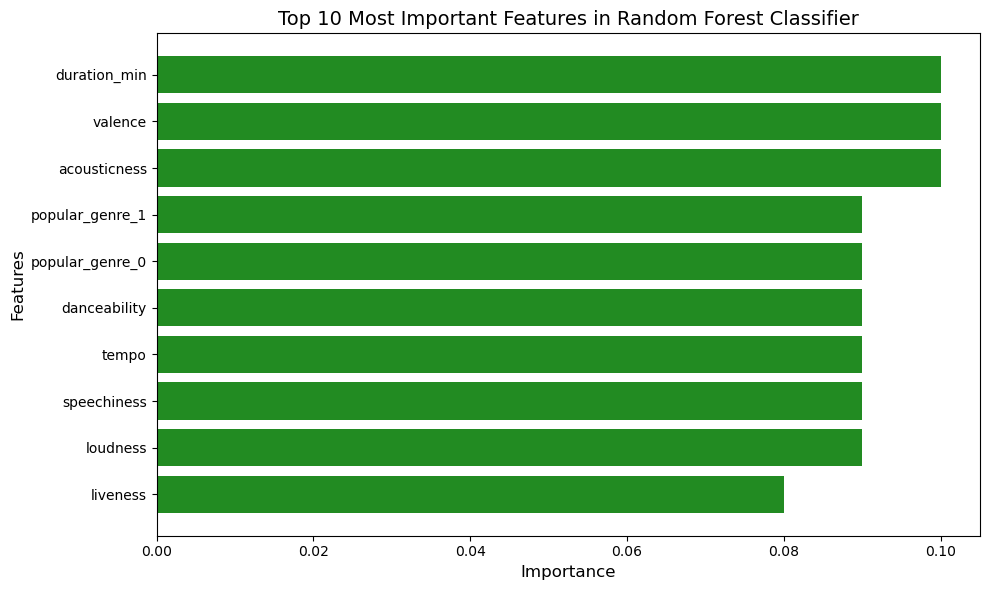

In [65]:
  # Extract feature importances from best_rf_clf
  import pandas as pd
  import numpy as np
  import matplotlib.pyplot as plt

  # Get feature importances
  importances = best_rf_clf.feature_importances_

  # Create a DataFrame with features and their importances
  feature_importance_df = pd.DataFrame({
      'features': feature_names,
      'importances': np.round(importances, 2)
  })

  # Sort by importance in descending order
  feature_importance_df = feature_importance_df.sort_values(by='importances', ascending=False)

  # Reset index for clean display
  feature_importance_df = feature_importance_df.reset_index(drop=True)

  print("Feature Importances for Best Random Forest Classifier:")
  print("="*50)
  print(feature_importance_df)

  # Visualize top 10 features
  top_n = 10
  top_features = feature_importance_df.head(top_n)

  plt.figure(figsize=(10, 6))
  plt.barh(top_features['features'], top_features['importances'], color='forestgreen')
  plt.xlabel('Importance', fontsize=12)
  plt.ylabel('Features', fontsize=12)
  plt.title(f'Top {top_n} Most Important Features in Random Forest Classifier', fontsize=14)
  plt.gca().invert_yaxis()
  plt.tight_layout()
  plt.show()

**Discussion Q1. Do the important features make sense within the context of music popularity?**

Yes.  Song length, emotional positivity, and production style significantly influence listener appeal.Popular songs tend to have optimal lengths (not too short or long), upbeat/positive emotional tones (high valence), and a balance between acoustic and electronic elements that suits contemporary tastes.


**Discussion Q2. Comparing `best_dt_clf` and `best_rf_clf`, which model provides better performance? Why might this be?**

Random forest is better. Because it addresses the Decision Tree's core weakness: high variance and overfitting.

**Discussion Q3. Are the important features consistent between `best_dt_clf` and `best_rf_clf`? Highlight the similarities and differences.**

Both models identify the same core features as important: valence (0.10 in both), acousticness (0.10 in both), tempo, danceability, speechiness, and loudness all appear in the top tier.

However, popular_genre dominates in the Decision Tree (0.19—nearly double any other feature) but is much more balanced in the Random Forest (0.09), showing equal importance to other features.

**Discussion Q4. Can conclusions be drawn from the Random Forest Classifier feature importances be considered as more robust than those drawn from the Decision Tree Classifier? Why or why not?**

 Yes, Random Forest feature importances are significantly more robust and trustworthy than those from a single Decision Tree.

 Because the Random Forest aggregates feature importances from hundreds of trees, each trained on different bootstrap samples with random feature subsets. This averaging process smooths out the noise and variability inherent in any single tree, producing more stable estimates that better reflect true underlying patterns rather than random fluctuations.

## Task 4: Decision Tree Regressor

The other model we will explore in this notebook is the Decision Tree Regressor. Unfortunately, this means we need to do a bit more data cleaning: as of now, `y_train` and `y_test` contain categorical features, meaning a decision tree regressor is inappropriate for predicting them. Thus, we start this task by picking and cleaning a new target variable: `popularity`.

> __Your Task__: As a first step towards setting up our training and testing data, we should check the distribution of our outcome variable. Plot a histogram showing the distribution of `popularity`. Does the distribution look fine, or does it warrant further cleaning? Why or why not?

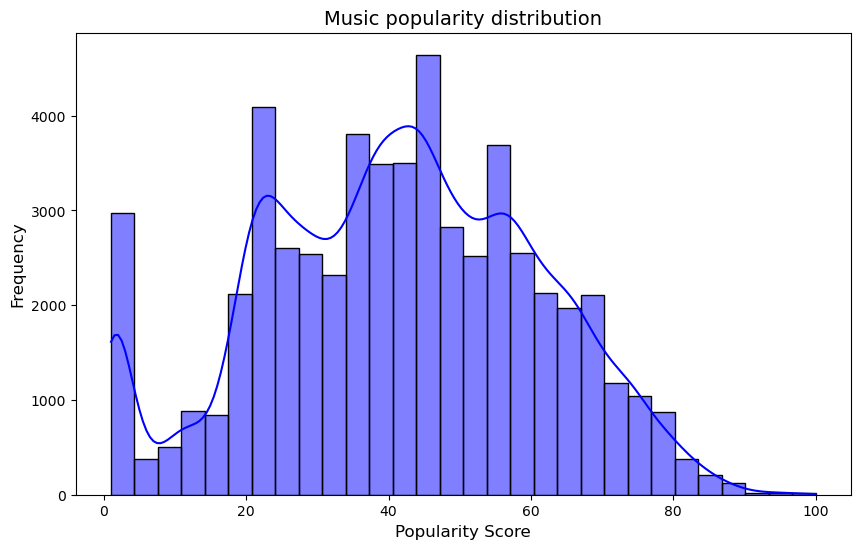

In [67]:
  # Check the distribution of the continuous popularity variable
  import matplotlib.pyplot as plt
  import seaborn as sns

  # Plot histogram of popularity
  plt.figure(figsize=(10, 6))
  sns.histplot(df_data['popularity'], kde=True, bins=30, color='blue')
  plt.xlabel('Popularity Score', fontsize=12)
  plt.ylabel('Frequency', fontsize=12)
  plt.title('Music popularity distribution', fontsize=14)
  plt.show()

The distribution shows a multi-modal pattern with several distinct peaks around popularity scores of 10, 25, 45, and 55, followed by a long tail extending to 80-90.

No need for further cleaning. Cuz we've already remove the ones whose popularity = 0. And decision tree regressors are non-parametric and don't assume normality, so it should be fine.

Now that we've looked at `popularity` and confirmed that it either looks fine or looks horrible (depending on your above conclusions), we should actually make our training and testing datasets.

> __Your Task__: Create `y_reg`, a copy of the `popularity` column of the original dataframe. Additionally, create `X_reg` by dropping `popularity` from `X_data`. Then, use `train_test_split` to create training and testing sets of the data. Use a random state of 42 and use 80% of the data for training. Print the shapes of the training and testing variables.

In [69]:
  # Create y_reg: copy of the popularity column from df_data
  y_reg = df_data['popularity'].copy()

  # Create X_reg: use X_data (which already has all processed features without popularity)
  # Since X_data was created from df_data with the same index, they should align
  X_reg = X_data.copy()

  # Verify alignment
  print("Verifying data alignment:")
  print(f"X_reg shape: {X_reg.shape}")
  print(f"y_reg shape: {y_reg.shape}")
  print(f"Index alignment check: {(X_reg.index == y_reg.index).all()}")

  # Split into training and testing sets (80% train, 20% test)
  X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
      X_reg, y_reg, test_size=0.2, random_state=42
  )

  # Print shapes of training and testing variables
  print("\n" + "="*50)
  print("Train/Test Split Results:")
  print("="*50)
  print(f"X_train_reg shape: {X_train_reg.shape}")
  print(f"X_test_reg shape: {X_test_reg.shape}")
  print(f"y_train_reg shape: {y_train_reg.shape}")
  print(f"y_test_reg shape: {y_test_reg.shape}")

  print(f"\nTraining set: {X_train_reg.shape[0]} samples ({X_train_reg.shape[0]/X_reg.shape[0]*100:.1f}%)")
  print(f"Testing set: {X_test_reg.shape[0]} samples ({X_test_reg.shape[0]/X_reg.shape[0]*100:.1f}%)")



Verifying data alignment:
X_reg shape: (56332, 17)
y_reg shape: (56332,)
Index alignment check: True

Train/Test Split Results:
X_train_reg shape: (45065, 17)
X_test_reg shape: (11267, 17)
y_train_reg shape: (45065,)
y_test_reg shape: (11267,)

Training set: 45065 samples (80.0%)
Testing set: 11267 samples (20.0%)


Now that we have our data preprocessed, we can fit a Decision Tree Regressor on the dataset. You can find the documentation for the regressor [here](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html).

> __Your Task__: Import the `DecisionTreeRegressor` class from `sklearn.tree`. Create, fit, and score the regression model, exploring different hyperparameters for the model listed on the documentation. Save the best performing model to a variable named `best_dt_reg` and report it's score on the testing dataset. Use a random state of 42 throughout.

In [70]:
  # Decision Tree Regressor with hyperparameter tuning
  from sklearn.tree import DecisionTreeRegressor

  # STEP 1: Test different max_depth values
  print("STEP 1: Testing max_depth for Decision Tree Regressor")
  print("="*60)

  max_depths = [3, 5, 7, 10, 15, 20, None]
  best_depth_score = -float('inf')
  best_depth = None

  for depth in max_depths:
      dt_reg = DecisionTreeRegressor(random_state=42, max_depth=depth)
      dt_reg.fit(X_train_reg, y_train_reg)
      train_score = dt_reg.score(X_train_reg, y_train_reg)
      test_score = dt_reg.score(X_test_reg, y_test_reg)
      print(f"max_depth={depth}: Train R²={train_score:.4f}, Test R²={test_score:.4f}")

      if test_score > best_depth_score:
          best_depth_score = test_score
          best_depth = depth

  print(f"\nBest max_depth: {best_depth} with test R²: {best_depth_score:.4f}")

  # STEP 2: Test criterion with best max_depth
  print("\n" + "="*60)
  print(f"STEP 2: Testing criterion with max_depth={best_depth}")
  print("="*60)

  criterions = ['squared_error', 'friedman_mse', 'absolute_error']
  best_criterion_score = -float('inf')
  best_criterion = 'squared_error'

  for criterion in criterions:
      dt_reg = DecisionTreeRegressor(random_state=42, max_depth=best_depth, criterion=criterion)
      dt_reg.fit(X_train_reg, y_train_reg)
      train_score = dt_reg.score(X_train_reg, y_train_reg)
      test_score = dt_reg.score(X_test_reg, y_test_reg)
      print(f"criterion={criterion}: Train R²={train_score:.4f}, Test R²={test_score:.4f}")

      if test_score > best_criterion_score:
          best_criterion_score = test_score
          best_criterion = criterion

  print(f"\nBest criterion: {best_criterion} with test R²: {best_criterion_score:.4f}")

  # STEP 3: Test min_samples_split
  print("\n" + "="*60)
  print(f"STEP 3: Testing min_samples_split")
  print(f"Using max_depth={best_depth}, criterion={best_criterion}")
  print("="*60)

  min_samples_splits = [2, 5, 10, 20, 50]
  best_split_score = -float('inf')
  best_split = 2

  for split in min_samples_splits:
      dt_reg = DecisionTreeRegressor(random_state=42, max_depth=best_depth,
                                     criterion=best_criterion, min_samples_split=split)
      dt_reg.fit(X_train_reg, y_train_reg)
      train_score = dt_reg.score(X_train_reg, y_train_reg)
      test_score = dt_reg.score(X_test_reg, y_test_reg)
      print(f"min_samples_split={split}: Train R²={train_score:.4f}, Test R²={test_score:.4f}")

      if test_score > best_split_score:
          best_split_score = test_score
          best_split = split

  print(f"\nBest min_samples_split: {best_split} with test R²: {best_split_score:.4f}")

  # STEP 4: Test min_samples_leaf
  print("\n" + "="*60)
  print(f"STEP 4: Testing min_samples_leaf")
  print(f"Using all best parameters found so far")
  print("="*60)

  min_samples_leafs = [1, 2, 5, 10, 20]
  best_leaf_score = -float('inf')
  best_leaf = 1

  for leaf in min_samples_leafs:
      dt_reg = DecisionTreeRegressor(random_state=42, max_depth=best_depth,
                                     criterion=best_criterion, min_samples_split=best_split,
                                     min_samples_leaf=leaf)
      dt_reg.fit(X_train_reg, y_train_reg)
      train_score = dt_reg.score(X_train_reg, y_train_reg)
      test_score = dt_reg.score(X_test_reg, y_test_reg)
      print(f"min_samples_leaf={leaf}: Train R²={train_score:.4f}, Test R²={test_score:.4f}")

      if test_score > best_leaf_score:
          best_leaf_score = test_score
          best_leaf = leaf

  print(f"\nBest min_samples_leaf: {best_leaf} with test R²: {best_leaf_score:.4f}")

  # FINAL: Create best model
  print("\n" + "="*60)
  print("FINAL BEST HYPERPARAMETERS FOR DECISION TREE REGRESSOR:")
  print("="*60)
  print(f"Criterion: {best_criterion}")
  print(f"Max Depth: {best_depth}")
  print(f"Min Samples Split: {best_split}")
  print(f"Min Samples Leaf: {best_leaf}")
  print(f"Best Test R² Score: {best_leaf_score:.4f}")

  # Create and train the best model
  best_dt_reg = DecisionTreeRegressor(
      random_state=42,
      criterion=best_criterion,
      max_depth=best_depth,
      min_samples_split=best_split,
      min_samples_leaf=best_leaf
  )

  best_dt_reg.fit(X_train_reg, y_train_reg)
  final_train_score = best_dt_reg.score(X_train_reg, y_train_reg)
  final_test_score = best_dt_reg.score(X_test_reg, y_test_reg)

  print(f"\nFinal best_dt_reg performance:")
  print(f"Training R² Score: {final_train_score:.4f}")
  print(f"Testing R² Score: {final_test_score:.4f}")



STEP 1: Testing max_depth for Decision Tree Regressor
max_depth=3: Train R²=0.1839, Test R²=0.1883
max_depth=5: Train R²=0.1983, Test R²=0.1997
max_depth=7: Train R²=0.2275, Test R²=0.2070
max_depth=10: Train R²=0.3028, Test R²=0.2115
max_depth=15: Train R²=0.5149, Test R²=0.1994
max_depth=20: Train R²=0.7546, Test R²=0.1657
max_depth=None: Train R²=0.9573, Test R²=0.0996

Best max_depth: 10 with test R²: 0.2115

STEP 2: Testing criterion with max_depth=10
criterion=squared_error: Train R²=0.3028, Test R²=0.2115
criterion=friedman_mse: Train R²=0.3028, Test R²=0.2115
criterion=absolute_error: Train R²=0.2572, Test R²=0.1814

Best criterion: squared_error with test R²: 0.2115

STEP 3: Testing min_samples_split
Using max_depth=10, criterion=squared_error
min_samples_split=2: Train R²=0.3028, Test R²=0.2115
min_samples_split=5: Train R²=0.3021, Test R²=0.2100
min_samples_split=10: Train R²=0.2995, Test R²=0.2109
min_samples_split=20: Train R²=0.2939, Test R²=0.2116
min_samples_split=50: T

Decision Trees are inherently interpretable, so we should attempt to interpret the results.

> __Your Task__: In the previous task, you created a Decision Tree Regressor named `best_dt_reg`. Let's interpret the regressor in two steps.

> First, use `graphviz` to visualize the tree. What patterns do you see in the tree? Which features are split on early, and which are split on later?

> Second, extract the `feature_importances_` from `best_dt_reg`, and create a DataFrame showing each feature and its importance. Sort the results in descending order of importance, and print the result.

> After making your table, answer the discussion questions below.

PART 1: Decision Tree Visualization
Displaying top 5 levels of the Decision Tree Regressor...


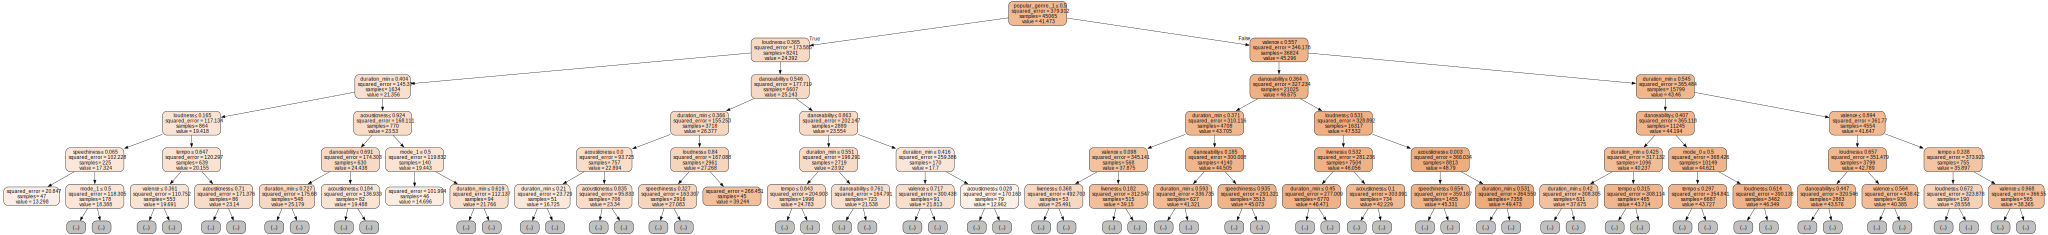


Tree structure summary:
Total tree depth: 10
Total number of leaves: 335

PART 2: Feature Importances

Feature Importances for Decision Tree Regressor:
            features  importances
0    popular_genre_1         0.62
1            valence         0.06
2       danceability         0.06
3       duration_min         0.04
4              tempo         0.04
5       acousticness         0.04
6           loudness         0.04
7           liveness         0.03
8        speechiness         0.03
9   instrumentalness         0.02
10   popular_genre_0         0.00
11    explicit_False         0.00
12     explicit_True         0.00
13            mode_0         0.00
14            mode_1         0.00
15  time_signature_0         0.00
16  time_signature_1         0.00

Visualizing top 10 most important features...


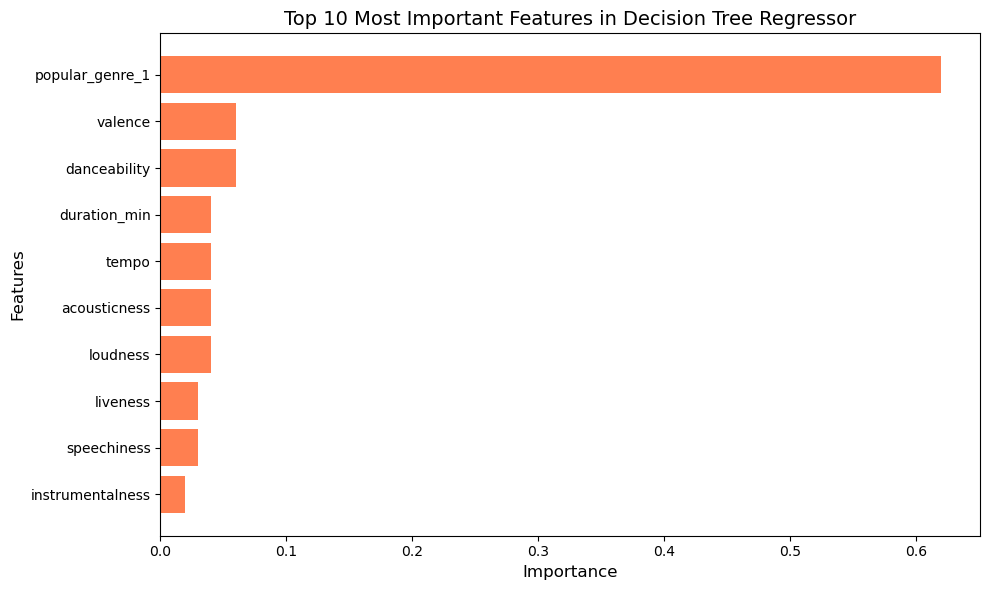

In [74]:
  # Visualize and interpret the Decision Tree Regressor
  from sklearn import tree
  import graphviz
  import pandas as pd
  import numpy as np
  import matplotlib.pyplot as plt

  # PART 1: Visualize the tree
  print("PART 1: Decision Tree Visualization")
  print("="*60)

  # Visualize top 5 levels for readability (full tree would be too large)
  dot_data = tree.export_graphviz(
      best_dt_reg,
      out_file=None,
      feature_names=feature_names,
      filled=True,
      rounded=True,
      special_characters=True,
      max_depth=5  # Show first 5 levels for clarity
  )
  graph = graphviz.Source(dot_data)
  print("Displaying top 5 levels of the Decision Tree Regressor...")
  display(graph)

  print("\nTree structure summary:")
  print(f"Total tree depth: {best_dt_reg.get_depth()}")
  print(f"Total number of leaves: {best_dt_reg.get_n_leaves()}")

  # PART 2: Extract and display feature importances
  print("\n" + "="*60)
  print("PART 2: Feature Importances")
  print("="*60)

  # Get feature importances
  importances = best_dt_reg.feature_importances_

  # Create DataFrame
  feature_importance_df = pd.DataFrame({
      'features': feature_names,
      'importances': np.round(importances, 2)
  })

  # Sort by importance
  feature_importance_df = feature_importance_df.sort_values(by='importances', ascending=False)
  feature_importance_df = feature_importance_df.reset_index(drop=True)

  print("\nFeature Importances for Decision Tree Regressor:")
  print(feature_importance_df)

  # Visualize top 10 features
  print("\nVisualizing top 10 most important features...")
  top_n = 10
  top_features = feature_importance_df.head(top_n)

  plt.figure(figsize=(10, 6))
  plt.barh(top_features['features'], top_features['importances'], color='coral')
  plt.xlabel('Importance', fontsize=12)
  plt.ylabel('Features', fontsize=12)
  plt.title(f'Top {top_n} Most Important Features in Decision Tree Regressor', fontsize=14)
  plt.gca().invert_yaxis()
  plt.tight_layout()
  plt.show()

**Discussion Q1. Do the important features make sense within the context of this music popularity dataset?**

Yes, but the feature importances reveal a striking pattern: popular_genre_1 dominates with 0.62 (62%) importance—far exceeding all other features combined. This is dramatically different from what we observed in the classifiers, where genre was important but more balanced with other features (0.19 in Decision Tree Classifier, 0.09 in Random Forest Classifier). But still make sense to me.


**Discussion Q2. Do these importances tell us anything about _causal_ linkages between our predictors and `popularity`? Why or why not?**

  No, these feature importances tell us nothing about causal relationships—they only reveal predictive associations. This is a critical distinction in data science: correlation does not imply causation.

**Discussion Q3. How do the visualizations of `best_dt_reg` and `best_dt_clf` differ?**

  - Classifier (best_dt_clf): Each node shows class distributions (e.g., "class = Popular" or "class = Not Popular") and the number of samples in each category, with leaf nodes predicting discrete class labels
  - Regressor (best_dt_reg): Each node displays a continuous mean value representing the average popularity score for songs reaching that node, with leaf nodes predicting specific numerical values (e.g., "value = 42.5")

**Discussion Q4. How does the "score" function differ between decision tree classifiers and regressors more broadly?**

  Decision Tree Classifier (Classification):
  - Metric: Accuracy = (Number of Correct Predictions) / (Total Predictions)
  - Range: 0.0 to 1.0 (0% to 100%)

  Decision Tree Regressor (Regression):
  - Metric: R² (Coefficient of Determination) = 1 - (Sum of Squared Residuals) / (Total Sum of Squares)
  - Range: -∞ to 1.0, though typically 0.0 to 1.0

Classification asks "which category?" (discrete), while regression asks "what value?" (continuous)—requiring different ways to measure success.

# Conclusion

In this assignment, we predict music popularity based on audio features.
- We modeled the relationship between audio features and music popularity with thre tree-based classifiers, attaining a fairly accurate result.
- We utilized the properties of the models to gain a better understanding of which features contributed the most to differentiating popular and non popular songs.
- Interpreting these results within the context of the dataset - along with our prior knowledge of factors related with music popularity - helped us better understand how different audio features impact a song's popularity.
- Comparing the decision tree and random forest classifiers shed light on how each model's pros and cons can impact the robustness of results.

In the later section, we switched our target to a numerical variable `popularity` and build a decision tree regressor to predict music popularity based on audio features. We follow the similar logic to visualize the model and interprete important features to validate model integrity. Specifically, we compared the decision tree classifier and regressor to provide an intuitive understanding of the difference between the two models in terms of node splitting criteria and scroing metrics.